In [1]:
!pip install tensorflow
!pip install gymnasium[classic-control]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.2 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1")

print("Observation Space:")
print(env.observation_space)

print("\nAction Space:")
print(env.action_space)

Observation Space:
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Action Space:
Discrete(2)


In [4]:
states = []
targets = []

In [5]:
for episode in range(100):

    state, info = env.reset()

    done = False

    while not done:

        action = env.action_space.sample()

        next_state, reward, terminated, truncated, info = env.step(action)

        states.append(state)

        targets.append(reward)

        state = next_state

        done = terminated or truncated

In [6]:
X = np.array(states)

y = np.array(targets)

print("State Shape:", X.shape)
print("Target Shape:", y.shape)

State Shape: (2187, 4)
Target Shape: (2187,)


In [7]:
model = Sequential([

    Dense(
        24,
        activation='relu',
        input_shape=(4,)
    ),

    Dense(
        24,
        activation='relu'
    ),

    Dense(
        1,
        activation='linear'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 745 (2.91 KB)

 Trainable params: 745 (2.91 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3409
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0456
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0076
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0026
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0010
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5604e-04
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.7007e-04
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.5457e-04
Epoch 10/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.5986e-04
Epoch 11/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.0009e-04
Epoch 12/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.5642e-04
Epoch 13/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2631e-04
Epoch 14/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.0116e-04
Epoch 15/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

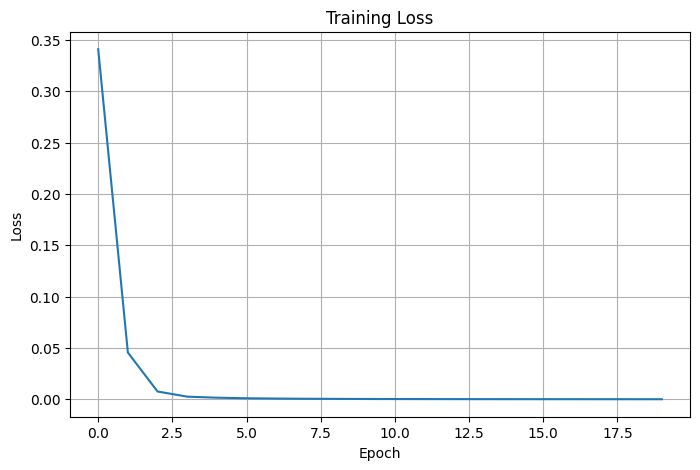

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

In [11]:
state, info = env.reset()

state = np.reshape(state,(1,4))

prediction = model.predict(state)

print("Predicted Value:")
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Value:
[[1.0055277]]


In [12]:
for i in range(5):

    state, info = env.reset()

    state = np.reshape(state,(1,4))

    value = model.predict(state, verbose=0)

    print(
        "State",
        i+1,
        "Predicted Value:",
        value[0][0]
    )

State 1 Predicted Value: 1.0025191
State 2 Predicted Value: 1.0044765
State 3 Predicted Value: 1.0010319
State 4 Predicted Value: 1.003926
State 5 Predicted Value: 0.99578726


In [15]:
model.save("value_prediction_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [17]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "value_prediction_model.h5",
    compile=False
)

print("Model Loaded")

Model Loaded


In [18]:
loss = model.evaluate(X,y)

print("Final Loss:",loss)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1717e-04
Final Loss: 0.00011717099550878629
